# CS2309 — SwiftEdit: notebook test

Notebook chạy thử **text-guided image editing** (SwiftEdit) trên **Mac MPS** hoặc **Google Colab (CUDA)**.

### Mac (local)
1. `pyenv local 3.12.10` → `.venv` → `pip install -r requirements-mac.txt`
2. `bash scripts/download_swiftedit_weights.sh` + `bash scripts/download_hf_models.sh`
3. Kernel **`.venv` (Python 3.12)**

### Google Colab (T4) — **không cần Google Drive**
1. **GPU T4:** Metadata notebook đã set `accelerator: GPU`, `colab.gpuType: T4` — **Colab web** thường tự chọn T4 khi mở file. **Colab extension:** vẫn cần **New Colab Server → GPU → T4** (extension chưa đọc metadata runtime). Nếu vẫn CPU: web → Runtime → Change runtime type → T4; extension → Remove Server rồi tạo server GPU mới.
2. Cell 1 **kiểm tra GPU** (`nvidia-smi`) ngay khi nhận Colab — thiếu GPU thì dừng, không clone/tải weights.
3. Chạy lần lượt các cell — notebook **tự nhận Colab**, **clone repo đề tài** `CS2309.CH201` (đã có `SwiftEdit/` + patch), tải weights/HF vào **`/content`** (mất khi reset runtime)
4. Repo **private** (mặc định): Colab → 🔑 **Secrets** → `GITHUB_TOKEN` = PAT GitHub. **Không** dán token vào notebook. (Extension: Secrets có thể chỉ hoạt động trên Colab web.)
5. Chỉnh `REPO_SLUG` ở cell 1 nếu fork

**Lưu ý:** Không clone repo Qualcomm riêng — dùng `SwiftEdit/` trong repo đề tài.

In [ ]:
import os
import subprocess
import sys
import time
from pathlib import Path

# Tự nhận Colab (hoặc gán tay IN_COLAB = True/False)
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False


_COLAB_GPU_ERR = (
    "Colab chưa có GPU.\n"
    "• Colab web: Runtime → Change runtime type → T4 GPU\n"
    "• Colab extension (VS Code/Cursor): Select Kernel → Colab → New Colab Server "
    "→ Hardware accelerator: GPU → T4, rồi Restart kernel\n"
    "• Đang nối server CPU: Colab: Remove Server, tạo server GPU mới (không đổi GPU trên cùng server)"
)


def _check_colab_gpu() -> None:
    """Kiểm tra GPU sớm (trước clone/pip) — không cần torch."""
    r = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
    )
    if r.returncode != 0 or not (r.stdout or "").strip():
        raise RuntimeError(_COLAB_GPU_ERR)
    names = [ln.strip() for ln in r.stdout.strip().splitlines() if ln.strip()]
    print("GPU OK (nvidia-smi):", ", ".join(names))


# --- Colab: chỉ clone repo đề tài → lưu trên /content (không mount Drive) ---
REPO_SLUG = "NguyenKz/CS2309.CH201"  # đổi nếu fork: "user/CS2309.CH201"
USE_PRIVATE_REPO = True  # True chỉ khi repo private + đã thêm secret GITHUB_TOKEN trên Colab UI

def _colab_repo_url():
    public_url = f"https://github.com/{REPO_SLUG}.git"
    if not USE_PRIVATE_REPO:
        return public_url
    try:
        from google.colab import userdata
        # DO NOT REMOVE IT, JUST ON LOCAL, AND IT WILL BE NERVER PUSH WITHOUT REMOVE THE TOKEN
        
        token = userdata.get("GITHUB_TOKEN")
        return f"https://{token}@github.com/{REPO_SLUG}.git"
    except Exception as e:
        print(
            "Không lấy được GITHUB_TOKEN (secret Colab). "
            "Dùng repo public hoặc: Colab → 🔑 Secrets → thêm GITHUB_TOKEN, rồi chạy lại.\n"
            f"Chi tiết: {e}\n"
            f"Fallback clone public: {public_url}"
        )
        return public_url


REPO_URL = _colab_repo_url() if IN_COLAB else f"https://github.com/{REPO_SLUG}.git"
COLAB_REPO_DIR = Path("/content/CS2309.CH201")

if IN_COLAB:
    _check_colab_gpu()
    if not (COLAB_REPO_DIR / "SwiftEdit" / "infer.py").exists():
        print(f"Cloning github.com/{REPO_SLUG} → {COLAB_REPO_DIR} ...")
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(COLAB_REPO_DIR)],
            check=True,
        )
    PROJECT_ROOT = COLAB_REPO_DIR
    # Cache Hugging Face trên ổ Colab (không Drive)
    os.environ.setdefault("HF_HOME", "/content/huggingface")
    os.environ.setdefault("HF_HUB_DOWNLOAD_TIMEOUT", "900")
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent
    elif not ((PROJECT_ROOT / "SwiftEdit" / "infer.py").exists()):
        for p in [Path.cwd(), *Path.cwd().parents]:
            if (p / "SwiftEdit" / "infer.py").exists():
                PROJECT_ROOT = p
                break

SWIFTEDIT_DIR = PROJECT_ROOT / "SwiftEdit"
WEIGHTS_DIR = SWIFTEDIT_DIR / "swiftedit_weights"
OUTPUT_DIR = PROJECT_ROOT / "results" / "notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

os.chdir(SWIFTEDIT_DIR)
if str(SWIFTEDIT_DIR) not in sys.path:
    sys.path.insert(0, str(SWIFTEDIT_DIR))

print("IN_COLAB:", IN_COLAB)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SWIFTEDIT_DIR:", SWIFTEDIT_DIR)
print("infer.py:", (SWIFTEDIT_DIR / "infer.py").is_file())
print("requirements.txt:", (SWIFTEDIT_DIR / "requirements.txt").is_file())
print("HF_HOME:", os.environ.get("HF_HOME", "(default ~/.cache)"))
print("Weights OK:", (WEIGHTS_DIR / "inverse_ckpt-120k").is_dir())
if IN_COLAB and not (SWIFTEDIT_DIR / "infer.py").is_file():
    raise FileNotFoundError(
        "Clone xong nhưng thiếu SwiftEdit/ — đảm bảo đã push SwiftEdit lên GitHub (không chỉ notebook)."
    )

GPU OK (nvidia-smi): Tesla T4
Cloning github.com/NguyenKz/CS2309.CH201 → /content/CS2309.CH201 ...
IN_COLAB: True
PROJECT_ROOT: /content/CS2309.CH201
SWIFTEDIT_DIR: /content/CS2309.CH201/SwiftEdit
infer.py: True
requirements.txt: True
HF_HOME: /content/huggingface
Weights OK: False


In [2]:
%pip install -q matplotlib ipywidgets


def _download_swiftedit_weights_inline(work_dir: Path) -> None:
    """Tải weights Qualcomm (~9.6 GB) — chạy trong notebook, không cần script ngoài."""
    base = "https://github.com/Qualcomm-AI-research/SwiftEdit/releases/download/v1.0"
    parts = ("aa", "ab", "ac", "ad", "ae")
    curl = ["curl", "-fL", "--retry", "10", "--retry-delay", "5", "--connect-timeout", "60", "-C", "-"]
    if (work_dir / "swiftedit_weights" / "inverse_ckpt-120k").is_dir():
        print("swiftedit_weights: đã có.")
        return
    for part in parts:
        fname = f"swiftedit_weights.tar.gz.part-{part}"
        dest = work_dir / fname
        if dest.exists() and dest.stat().st_size > 1_000_000:
            print(f"skip {fname}")
            continue
        print(f"download {fname} ...")
        subprocess.run([*curl, "-o", str(dest), f"{base}/{fname}"], check=True, cwd=work_dir)
    out_tar = work_dir / "swiftedit_weights.tar.gz"
    print("ghép archive...")
    with open(out_tar, "wb") as out:
        for part in parts:
            out.write((work_dir / f"swiftedit_weights.tar.gz.part-{part}").read_bytes())
    print("giải nén...")
    subprocess.run(["tar", "zxf", str(out_tar)], check=True, cwd=work_dir)
    print("done:", work_dir / "swiftedit_weights")


def _download_hf_minimal() -> None:
    from huggingface_hub import hf_hub_download, snapshot_download

    p = ["scheduler/*", "vae/*", "tokenizer/*", "text_encoder/*"]
    print("SD2.1 aux...")
    snapshot_download("Manojb/stable-diffusion-2-1-base", allow_patterns=p)
    print("sd-turbo...")
    snapshot_download("stabilityai/sd-turbo", allow_patterns=p)
    print("IP-Adapter encoder...")
    for f in (
        "models/image_encoder/config.json",
        "models/image_encoder/model.safetensors",
        "models/image_encoder/pytorch_model.bin",
    ):
        hf_hub_download("h94/IP-Adapter", f)
    print("HF done.")


if IN_COLAB:
    for v in ("PROJECT_ROOT", "SWIFTEDIT_DIR", "WEIGHTS_DIR"):
        assert v in globals(), f"Chạy cell 1 (paths) trước — thiếu {v}"

    REQ_FILE = SWIFTEDIT_DIR / "requirements.txt"
    if not REQ_FILE.is_file():
        raise FileNotFoundError(
            f"Không thấy {REQ_FILE}\n"
            "Push repo GitHub có đủ SwiftEdit/ (infer.py, requirements.txt), rồi Restart + cell 1."
        )
    print("pip install từ:", REQ_FILE, "(stack mới: transformers≥4.46, diffusers≥0.32)")
    # Colab: giữ torch runtime; nâng transformers/diffusers/peft (không hạ về 0.22).
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-U", "-r", str(REQ_FILE)],
        check=True,
    )

    def _pkg_version(pkg: str) -> str:
        import importlib.metadata as _im

        return _im.version(pkg)

    def _require_min_version(pkg: str, min_ver: str) -> None:
        from packaging.version import Version

        got = _pkg_version(pkg)
        print(f"{pkg}: {got} (≥ {min_ver})")
        if Version(got) < Version(min_ver):
            raise RuntimeError(
                f"{pkg} {got} < {min_ver}. Restart kernel → chạy lại cell Setup."
            )

    _require_min_version("transformers", "4.46.0")
    _require_min_version("diffusers", "0.32.0")

    import numpy as np

    print("numpy:", np.__version__)
    import torchvision  # smoke test ABI

    print("torchvision:", torchvision.__version__)
    import diffusers  # noqa: F401
    from transformers import EncoderDecoderCache  # noqa: F401

    print("diffusers + transformers (EncoderDecoderCache) OK")

    if not (WEIGHTS_DIR / "inverse_ckpt-120k").is_dir():
        print("Tải swiftedit_weights (~9.6 GB) →", SWIFTEDIT_DIR)
        _download_swiftedit_weights_inline(SWIFTEDIT_DIR)

    print("Tải HF tối thiểu →", os.environ.get("HF_HOME", "/content/huggingface"))
    _download_hf_minimal()
    os.chdir(SWIFTEDIT_DIR)
else:
    pass

import torch  # noqa: E402 — sau pip / smoke test torchvision ở Colab

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
if IN_COLAB:
    print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
print("mps:", getattr(torch.backends, "mps", None) and torch.backends.mps.is_available())

if IN_COLAB and not torch.cuda.is_available():
    _gpu_err = globals().get(
        "_COLAB_GPU_ERR",
        "Colab chưa có GPU — chạy lại cell 1 hoặc bật T4 (xem hướng dẫn đầu notebook).",
    )
    raise RuntimeError(_gpu_err)

for name, p in [
    ("inverse_ckpt", WEIGHTS_DIR / "inverse_ckpt-120k"),
    ("sbv2", WEIGHTS_DIR / "sbv2_0.5"),
    ("ip_adapter", WEIGHTS_DIR / "ip_adapter_ckpt-90k" / "ip_adapter.bin"),
]:
    if not p.exists():
        raise FileNotFoundError(f"Thiếu {name}: {p}\nChạy lại cell trên (tải weights).")
print("Weights OK — có thể chạy cell Load models.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 64.2 MB/s eta 0:00:0000:0100:01
pip install từ: /content/CS2309.CH201/SwiftEdit/requirements.txt (stack mới: transformers≥4.46, diffusers≥0.32)
transformers: 4.57.6 (≥ 4.46.0)
diffusers: 0.35.2 (≥ 0.32.0)
numpy: 2.0.2
torchvision: 0.26.0+cu128
diffusers + transformers (EncoderDecoderCache) OK
Tải swiftedit_weights (~9.6 GB) → /content/CS2309.CH201/SwiftEdit
download swiftedit_weights.tar.gz.part-aa ...
download swiftedit_weights.tar.gz.part-ab ...
download swiftedit_weights.tar.gz.part-ac ...
download swiftedit_weights.tar.gz.part-ad ...
download swiftedit_weights.tar.gz.part-ae ...
ghép archive...
giải nén...
done: /content/CS2309.CH201/SwiftEdit/swiftedit_weights
Tải HF tối thiểu → /content/huggingface
SD2.1 aux...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/346 [00:00<?, ?B/s]

...

IP-Adapter encoder...


config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

models/image_encoder/model.safetensors:   0%|          | 0.00/2.53G [00:00<?, ?B/s]

models/image_encoder/pytorch_model.bin:   0%|          | 0.00/2.53G [00:00<?, ?B/s]

HF done.
torch: 2.11.0+cu128
cuda: True
GPU: Tesla T4
mps: False
Weights OK — có thể chạy cell Load models.


In [3]:
# Cần chạy xong cell Setup (weights + HF) trước.
# Cần transformers≥4.46 + diffusers≥0.32 (cell Setup). Sau đổi version: Restart kernel → Setup → Load.
assert "SWIFTEDIT_DIR" in globals(), "Chạy cell 1 (paths) trước."
from packaging.version import Version
import importlib.metadata as _im

for _pkg, _min in (("transformers", "4.46.0"), ("diffusers", "0.32.0")):
    _v = _im.version(_pkg)
    if Version(_v) < Version(_min):
        raise RuntimeError(f"{_pkg}=={_v} — cần ≥{_min}. Chạy lại cell Setup.")
    print(f"{_pkg}: {_v}")
from transformers import EncoderDecoderCache  # noqa: F401
assert (WEIGHTS_DIR / "inverse_ckpt-120k").is_dir(), f"Thiếu weights: {WEIGHTS_DIR}"

os.chdir(SWIFTEDIT_DIR)
if str(SWIFTEDIT_DIR) not in sys.path:
    sys.path.insert(0, str(SWIFTEDIT_DIR))

from infer import SWIFTEDIT_WEIGHTS_ROOT, edit_image, get_device
from models import AuxiliaryModel, IPSBV2Model, InverseModel

device = get_device()
print("Using device:", device)
if IN_COLAB and device != "cuda":
    print("Cảnh báo: Colab nên dùng cuda — bật GPU (web: Runtime → T4; extension: New Colab Server → GPU).")

inverse_ckpt = os.path.join(SWIFTEDIT_WEIGHTS_ROOT, "inverse_ckpt-120k")
path_unet_sb = os.path.join(SWIFTEDIT_WEIGHTS_ROOT, "sbv2_0.5")
ip_ckpt = os.path.join(SWIFTEDIT_WEIGHTS_ROOT, "ip_adapter_ckpt-90k/ip_adapter.bin")

for label, p in [("inverse", inverse_ckpt), ("sbv2", path_unet_sb), ("ip", ip_ckpt)]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Thiếu {label}: {p}")

if IN_COLAB and torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Loading models (lần đầu ~2–5 phút trên Colab T4)...")
t0 = time.time()
inverse_model = InverseModel(inverse_ckpt, device=device)
aux_model = AuxiliaryModel(device=device)
ip_sb_model = IPSBV2Model(
    path_unet_sb, ip_ckpt, aux_model, device=device, with_ip_mask_controller=True
)
print(f"Models ready in {time.time() - t0:.1f}s")

transformers: 4.57.6
diffusers: 0.35.2
Using device: cuda
Loading models (lần đầu ~2–5 phút trên Colab T4)...


The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 110000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


Models ready in 75.5s


## Tham số test

Đổi `PRESET` hoặc gán trực tiếp `IMG_PATH`, `SRC_P`, `EDIT_P`.

In [4]:
PRESETS = {
    "woman": {
        "img": "assets/imgs_demo/woman_face.jpg",
        "src_p": "woman",
        "edit_p": "Taylor Swift",
    },
    "dog": {
        "img": "assets/imgs_demo/02.jpg",
        "src_p": "dog",
        "edit_p": "dog with mouth opened",
    },
}

PRESET = "dog"  # "woman" | "dog"

cfg = PRESETS[PRESET]
IMG_PATH = cfg["img"]
SRC_P = cfg["src_p"]
EDIT_P = cfg["edit_p"]

# Hyperparameter (ablation — giữ mặc định paper/repo)
SCALE_TA = 1.0
SCALE_EDIT = 0.2
SCALE_NON_EDIT = 1.0
CLAMP_RATE = 3.0
MASK_THRESHOLD = 0.5

print(f"Preset: {PRESET}")
print(f"  image: {IMG_PATH}")
print(f"  src:   {SRC_P!r}")
print(f"  edit:  {EDIT_P!r}")

Preset: dog
  image: assets/imgs_demo/02.jpg
  src:   'dog'
  edit:  'dog with mouth opened'


Edit 'dog' -> 'dog with mouth opened' in 1.3s
Saved: /content/CS2309.CH201/results/notebook/nb_dog_dog_to_dog_with_mouth_opened.png


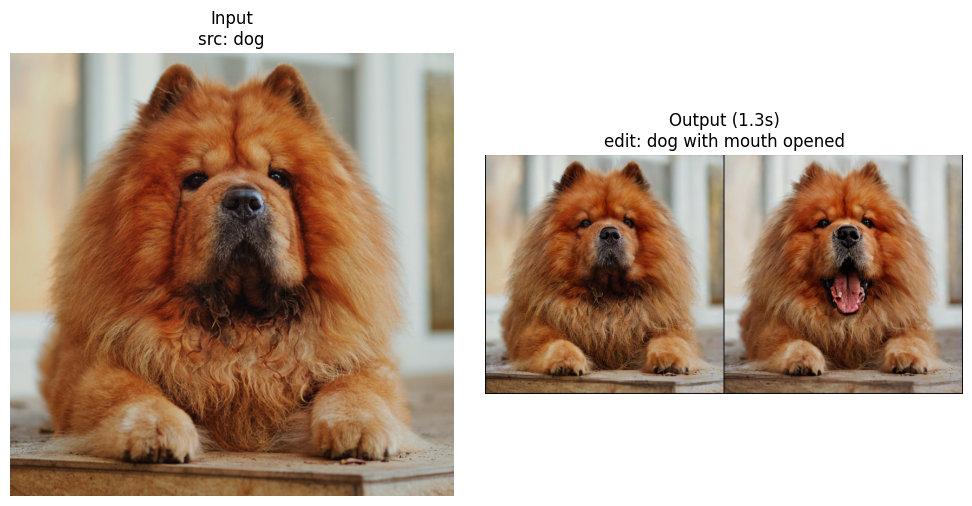

In [7]:
from PIL import Image
from torchvision.utils import save_image

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ModuleNotFoundError:
    HAS_MPL = False
    from IPython.display import display

assert Path(IMG_PATH).is_file(), f"Không thấy ảnh: {IMG_PATH}"

t0 = time.time()

result = edit_image(
    IMG_PATH,
    SRC_P,
    EDIT_P,
    inverse_model,
    aux_model,
    ip_sb_model,
    scale_ta=SCALE_TA,
    scale_edit=SCALE_EDIT,
    scale_non_edit=SCALE_NON_EDIT,
    clamp_rate=CLAMP_RATE,
    mask_threshold=MASK_THRESHOLD,
)
elapsed = time.time() - t0
print(f"Edit {SRC_P!r} -> {EDIT_P!r} in {elapsed:.1f}s")

out_name = f"nb_{PRESET}_{SRC_P}_to_{EDIT_P}.png".replace(" ", "_")
out_path = OUTPUT_DIR / out_name
save_image(result, out_path)
print("Saved:", out_path)

# Hiển thị input | output
input_img = Image.open(IMG_PATH).convert("RGB").resize((512, 512))
output_img = Image.open(out_path).convert("RGB")

if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(input_img)
    axes[0].set_title(f"Input\nsrc: {SRC_P}")
    axes[0].axis("off")
    axes[1].imshow(output_img)
    axes[1].set_title(f"Output ({elapsed:.1f}s)\nedit: {EDIT_P}")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
else:
    # Fallback nếu chưa cài matplotlib — chạy lại cell 2 (%pip install)
    w, h = input_img.size
    combined = Image.new("RGB", (w * 2, h))
    combined.paste(input_img, (0, 0))
    combined.paste(output_img, (w, 0))
    display(combined)

### Upload ảnh riêng + chạy inference

1. Chạy các cell phía trên (đến **Load models**).
2. **Colab extension (Cursor/VS Code):** `files.upload()` **không hoạt động** — chuột phải ảnh local → **Upload to Colab** → dán path vào ô **Đường dẫn** (hoặc bấm **Dùng ảnh demo**). Bật setting `colab.uploading` nếu chưa thấy menu.
3. **Colab web:** có thể bấm **Chọn ảnh (Colab)** hoặc dán path.
4. **Áp dụng ảnh** → **Chạy SwiftEdit**. (FileUpload chỉ khi chạy **local Mac**.)

In [6]:
import sys

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except ImportError:
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from IPython.display import display, clear_output

from PIL import Image
from torchvision.utils import save_image

try:
    import matplotlib.pyplot as plt

    HAS_MPL = True
except ModuleNotFoundError:
    HAS_MPL = False

_USE_COLAB_UPLOAD = bool(globals().get("IN_COLAB"))
_UPLOAD_CACHE: dict = {"name": None, "bytes": None, "path": None}


def _is_colab_vscode_extension() -> bool:
    """files.upload() cần Colab web UI — không chạy trong Colab extension (Cursor/VS Code)."""
    if not _USE_COLAB_UPLOAD:
        return False
    if os.environ.get("VSCODE_PID") or os.environ.get("VSCODE_INJECTION"):
        return True
    try:
        from IPython import get_ipython

        ip = get_ipython()
        mod = (ip.__class__.__module__ if ip else "") or ""
        if "vscode" in mod.lower() or "cursor" in mod.lower():
            return True
    except Exception:
        pass
    return False


_COLAB_BROWSER_PICK = _USE_COLAB_UPLOAD and not _is_colab_vscode_extension()
_IN_COLAB_EXTENSION = _USE_COLAB_UPLOAD and _is_colab_vscode_extension()


def _suggest_image_path() -> str:
    candidates = []
    if globals().get("SWIFTEDIT_DIR"):
        candidates.append(Path(SWIFTEDIT_DIR) / "assets" / "imgs_demo" / "02.jpg")
    candidates.extend(
        [
            Path("/content/CS2309.CH201/SwiftEdit/assets/imgs_demo/02.jpg"),
            Path("/content/photo.jpg"),
            Path("/content/upload.jpg"),
        ]
    )
    for c in candidates:
        if c.is_file():
            return str(c.resolve())
    return ""


_default_path = _suggest_image_path()
if _IN_COLAB_EXTENSION and _default_path:
    _path_hint = f"<code>{_default_path}</code>"
else:
    _path_hint = "<code>/content/...</code>"

upload_help = widgets.HTML(
    value=(
        "<b>Colab extension:</b> Chuột phải ảnh (Explorer) → <b>Upload to Colab</b> → "
        f"dán path (vd. {_path_hint}) → <b>Áp dụng ảnh</b>. "
        "<i>Không dùng「Chọn ảnh (Colab)」— chỉ hoạt động trên colab.research.google.com.</i>"
        if _IN_COLAB_EXTENSION
        else (
            "<b>Colab web:</b> <i>Chọn ảnh (Colab)</i> hoặc dán path <code>/content/...</code>."
            if _COLAB_BROWSER_PICK
            else "<b>Colab:</b> dán đường dẫn ảnh trên server."
        )
        if _USE_COLAB_UPLOAD
        else "<b>Local:</b> ô Upload hoặc đường dẫn file trên máy."
    )
)
btn_colab_pick = widgets.Button(
    description="Chọn ảnh (Colab web)",
    button_style="primary",
    icon="upload",
    tooltip="Chỉ Colab trên trình duyệt — không dùng trong Cursor/VS Code extension",
)
btn_use_demo = widgets.Button(description="Dùng ảnh demo (02.jpg)", button_style="")
btn_list_content = widgets.Button(description="Liệt kê /content", button_style="")
path_widget = widgets.Text(
    value=_default_path,
    description="Đường dẫn",
    placeholder="/content/ảnh.jpg sau khi Upload to Colab",
    layout=widgets.Layout(width="520px"),
)
upload_widget = None
if not _USE_COLAB_UPLOAD:
    upload_widget = widgets.FileUpload(
        accept=".jpg,.jpeg,.png",
        multiple=False,
        description="Ảnh",
    )

src_widget = widgets.Text(
    value="dog",
    description="src_p",
    placeholder="mô tả ảnh gốc (có thể ngắn)",
    layout=widgets.Layout(width="420px"),
)
edit_widget = widgets.Text(
    value="dog with mouth opened",
    description="edit_p",
    placeholder="mô tả chỉnh sửa (bắt buộc)",
    layout=widgets.Layout(width="420px"),
)
btn_apply = widgets.Button(description="Áp dụng ảnh", button_style="info")
btn_run = widgets.Button(description="Chạy SwiftEdit", button_style="success")
_status_init = "<i>Chưa có ảnh.</i>"
if _default_path:
    _status_init = (
        f"<i>Gợi ý path:</i> <code>{_default_path}</code> — "
        f"<b>Áp dụng ảnh</b> nếu file đã có trên server."
    )
status = widgets.HTML(value=_status_init)
out = widgets.Output()


def _normalize_upload_bytes(content) -> bytes:
    if content is None:
        return b""
    if isinstance(content, bytes):
        return content
    if hasattr(content, "tobytes"):
        return content.tobytes()
    return bytes(content)


def _parse_one_upload_entry(entry) -> tuple[str, bytes]:
    if isinstance(entry, dict):
        if "content" in entry or "data" in entry:
            name = entry.get("name") or entry.get("filename") or "upload.jpg"
            raw = entry.get("content", entry.get("data"))
            return name, _normalize_upload_bytes(raw)
        if entry:
            name, meta = next(iter(entry.items()))
            if isinstance(meta, dict):
                raw = meta.get("content", meta.get("data"))
                return name, _normalize_upload_bytes(raw)
            return name, _normalize_upload_bytes(meta)
    name = getattr(entry, "name", None) or getattr(entry, "filename", "upload.jpg")
    raw = getattr(entry, "content", None)
    return name, _normalize_upload_bytes(raw)


def _parse_fileupload_value(val):
    """ipywidgets 7: dict[name→meta]; 8+: tuple/list[dict]; đôi khi dict phẳng {name, content}."""
    if val is None:
        return None
    if isinstance(val, dict):
        if not val:
            return None
        if "content" in val or "data" in val:
            return _parse_one_upload_entry(val)
        return _parse_one_upload_entry(val)
    if isinstance(val, (tuple, list)):
        if not val:
            return None
        return _parse_one_upload_entry(val[0])
    return _parse_one_upload_entry(val)


def _set_upload_cache(name: str, data: bytes, path: Path | None = None) -> None:
    _UPLOAD_CACHE["name"] = name
    _UPLOAD_CACHE["bytes"] = data
    _UPLOAD_CACHE["path"] = str(path.resolve()) if path else None


def _read_from_path_field() -> tuple[str, bytes] | None:
    raw = path_widget.value.strip()
    if not raw:
        return None
    p = Path(raw).expanduser()
    if not p.is_file():
        raise ValueError(f"Không thấy file trên server: {p.resolve()}")
    ext = p.suffix.lower()
    if ext not in {".jpg", ".jpeg", ".png"}:
        raise ValueError(f"Chỉ .jpg/.png — file: {p.name}")
    data = p.read_bytes()
    return p.name, data


def _cache_upload_from_widget():
    if upload_widget is None:
        return False
    parsed = _parse_fileupload_value(upload_widget.value)
    if parsed is None:
        return False
    name, data = parsed
    if not data:
        return False
    _set_upload_cache(name, data)
    return True


def _on_upload_change(change):
    if change.get("name") != "value" or upload_widget is None:
        return
    if not _cache_upload_from_widget():
        status.value = "<i>Chưa có file — chọn .jpg / .png.</i>"
        return
    name = _UPLOAD_CACHE["name"]
    nbytes = len(_UPLOAD_CACHE["bytes"])
    status.value = (
        f"<b>Đã chọn file:</b> <code>{name}</code> "
        f"({nbytes:,} bytes) — bấm <b>Áp dụng ảnh</b>."
    )


def _read_upload_bytes_and_name():
    if _UPLOAD_CACHE.get("bytes"):
        return _UPLOAD_CACHE["name"], _UPLOAD_CACHE["bytes"]

    from_path = _read_from_path_field()
    if from_path is not None:
        name, data = from_path
        _set_upload_cache(name, data, Path(path_widget.value.strip()))
        return name, data

    if _cache_upload_from_widget():
        return _UPLOAD_CACHE["name"], _UPLOAD_CACHE["bytes"]

    if _IN_COLAB_EXTENSION:
        raise ValueError(
            "Chưa có ảnh. Colab extension: Explorer → Upload to Colab → dán path đầy đủ "
            "vào ô Đường dẫn → Áp dụng ảnh. Hoặc bấm「Dùng ảnh demo」. "
            "(Không dùng Chọn ảnh Colab web — không hỗ trợ extension.)"
        )
    if _USE_COLAB_UPLOAD:
        raise ValueError(
            "Chưa có ảnh — dán path /content/... hoặc bấm Chọn ảnh (Colab web)."
        )
    raise ValueError("Chưa có ảnh — chọn Upload hoặc điền đường dẫn file.")


def on_colab_pick(_):
    with out:
        clear_output(wait=True)
        if _IN_COLAB_EXTENSION:
            status.value = (
                "<span style='color:orange'><b>Colab extension:</b> không dùng nút này. "
                "Upload to Colab (Explorer) → dán path → Áp dụng ảnh.</span>"
            )
            print("Colab extension: dùng ô「Đường dẫn」+ Upload to Colab, không dùng files.upload().")
            return
        try:
            from google.colab import files

            print("Colab web — chọn 1 ảnh .jpg/.png trong hộp thoại …")
            uploaded = files.upload()
            if not uploaded:
                status.value = "<span style='color:red'>Không chọn file.</span>"
                return
            name = next(iter(uploaded.keys()))
            data = _normalize_upload_bytes(uploaded[name])
            if not data:
                raise ValueError(f"File rỗng: {name}")
            _set_upload_cache(name, data)
            path_widget.value = ""
            status.value = (
                f"<b>Đã chọn (Colab web):</b> <code>{name}</code> ({len(data):,} bytes) "
                f"— bấm <b>Áp dụng ảnh</b>."
            )
            print(f"OK: {name!r} ({len(data):,} bytes)")
        except Exception as e:
            status.value = f"<span style='color:red'>Lỗi chọn ảnh: {e}</span>"


def on_use_demo(_):
    p = _suggest_image_path()
    with out:
        clear_output(wait=True)
        if not p:
            status.value = (
                "<span style='color:red'>Không thấy ảnh demo — chạy cell 1 (clone repo) "
                "hoặc Upload to Colab rồi dán path.</span>"
            )
            return
        path_widget.value = p
        _UPLOAD_CACHE.update({"name": None, "bytes": None, "path": None})
        status.value = f"<b>Demo:</b> <code>{p}</code> — bấm <b>Áp dụng ảnh</b>."
        print(f"Đường dẫn demo: {p}")


def on_list_content(_):
    with out:
        clear_output(wait=True)
        print("=== /content (ảnh .jpg/.png) ===")
        root = Path("/content")
        if not root.is_dir():
            print("(không có /content)")
            return
        for p in sorted(root.rglob("*")):
            if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                print(p.resolve())
        print("--- gợi ý demo ---")
        print(_suggest_image_path() or "(chưa có 02.jpg — clone repo hoặc upload)")


def _save_uploaded_image() -> Path:
    cached_path = _UPLOAD_CACHE.get("path")
    if cached_path and Path(cached_path).is_file():
        p = Path(cached_path)
        print(f"Dùng file trên server: {p.resolve()}")
        return p

    name, data = _read_upload_bytes_and_name()
    print(f"Upload: {name!r} ({len(data):,} bytes)")
    ext = Path(name).suffix.lower()
    if ext not in {".jpg", ".jpeg", ".png"}:
        ext = ".jpg"
    path = OUTPUT_DIR / f"upload{ext}"
    path.write_bytes(data)
    _set_upload_cache(name, data, path)
    return path


def on_apply(_):
    with out:
        clear_output(wait=True)
        try:
            upload_name, _ = _read_upload_bytes_and_name()
            path = _save_uploaded_image()
            global IMG_PATH, SRC_P, EDIT_P
            IMG_PATH = str(path)
            SRC_P = src_widget.value.strip()
            EDIT_P = edit_widget.value.strip()
            if not EDIT_P:
                raise ValueError("edit_p không được để trống.")
            preview = Image.open(path).convert("RGB")
            preview.thumbnail((320, 320))
            status.value = (
                f"<b>OK</b> — file gốc: <code>{upload_name}</code><br>"
                f"đã lưu: <code>{path.resolve()}</code><br>"
                f"src: <code>{SRC_P}</code> → edit: <code>{EDIT_P}</code>"
            )
            print(f"IMG_PATH = {IMG_PATH}")
            print(f"SRC_P = {SRC_P!r}")
            print(f"EDIT_P = {EDIT_P!r}")
            display(preview)
        except Exception as e:
            status.value = f"<span style='color:red'>Lỗi: {e}</span>"


def on_run(_):
    with out:
        clear_output(wait=True)
        try:
            if "inverse_model" not in globals():
                raise RuntimeError("Chưa load model — chạy cell 'Load models' trước.")
            path = Path(IMG_PATH) if "IMG_PATH" in globals() and IMG_PATH else None
            if path is None or not path.is_file():
                path = _save_uploaded_image()
                globals()["IMG_PATH"] = str(path)
            SRC_P_local = src_widget.value.strip()
            EDIT_P_local = edit_widget.value.strip()
            if not EDIT_P_local:
                raise ValueError("edit_p không được để trống.")
            globals()["SRC_P"] = SRC_P_local
            globals()["EDIT_P"] = EDIT_P_local

            src_file = _UPLOAD_CACHE.get("name") or path.name
            print(f"Đang edit {src_file!r} ({path.resolve()}): {SRC_P_local!r} → {EDIT_P_local!r} ...")
            t0 = time.time()
            result = edit_image(
                str(path),
                SRC_P_local,
                EDIT_P_local,
                inverse_model,
                aux_model,
                ip_sb_model,
                scale_ta=SCALE_TA if "SCALE_TA" in globals() else 1.0,
                scale_edit=SCALE_EDIT if "SCALE_EDIT" in globals() else 0.2,
                scale_non_edit=SCALE_NON_EDIT if "SCALE_NON_EDIT" in globals() else 1.0,
                clamp_rate=CLAMP_RATE if "CLAMP_RATE" in globals() else 3.0,
                mask_threshold=MASK_THRESHOLD if "MASK_THRESHOLD" in globals() else 0.5,
            )
            elapsed = time.time() - t0
            safe = "".join(c if c.isalnum() or c in "-_" else "_" for c in EDIT_P_local)[:40]
            out_path = OUTPUT_DIR / f"nb_upload_{safe}.png"
            save_image(result, out_path)
            print(f"Xong trong {elapsed:.1f}s — lưu: {out_path}")

            input_img = Image.open(path).convert("RGB").resize((512, 512))
            output_img = Image.open(out_path).convert("RGB")
            status.value = (
                f"<b>Hoàn tất</b> ({elapsed:.1f}s) — <code>{out_path.name}</code>"
            )

            if HAS_MPL:
                fig, axes = plt.subplots(1, 2, figsize=(10, 5))
                axes[0].imshow(input_img)
                axes[0].set_title(f"Input\n{SRC_P_local}")
                axes[0].axis("off")
                axes[1].imshow(output_img)
                axes[1].set_title(f"Output\n{EDIT_P_local}")
                axes[1].axis("off")
                plt.tight_layout()
                plt.show()
            else:
                w, h = input_img.size
                combined = Image.new("RGB", (w * 2, h))
                combined.paste(input_img, (0, 0))
                combined.paste(output_img, (w, 0))
                display(combined)
        except Exception as e:
            status.value = f"<span style='color:red'>Lỗi: {e}</span>"
            raise


if upload_widget is not None:
    upload_widget.observe(_on_upload_change, names="value")

btn_colab_pick.on_click(on_colab_pick)
btn_use_demo.on_click(on_use_demo)
btn_list_content.on_click(on_list_content)
btn_apply.on_click(on_apply)
btn_run.on_click(on_run)

_ui_rows = [
    widgets.HTML("<b>Upload + prompt</b>"),
    upload_help,
]
if _USE_COLAB_UPLOAD:
    _tool_row = [btn_use_demo, btn_list_content]
    if _COLAB_BROWSER_PICK:
        _tool_row.insert(0, btn_colab_pick)
    _ui_rows.extend([widgets.HBox(_tool_row), path_widget])
else:
    _ui_rows.append(upload_widget)
    _ui_rows.append(path_widget)
_ui_rows.extend(
    [
        src_widget,
        edit_widget,
        widgets.HBox([btn_apply, btn_run]),
        status,
        out,
    ]
)
print(
    "Upload mode:",
    "Colab extension (path / Upload to Colab)" if _IN_COLAB_EXTENSION else (
        "Colab web" if _COLAB_BROWSER_PICK else ("Colab path" if _USE_COLAB_UPLOAD else "Local")
    ),
)
if _default_path:
    print("Demo path:", _default_path)
display(widgets.VBox(_ui_rows))

Upload mode: Colab web
Demo path: /content/CS2309.CH201/SwiftEdit/assets/imgs_demo/02.jpg
